# 02 - Improved Results Visualization

This notebook reloads the saved improved model and artifacts from `improved model/results/`.
It prefers existing saved validation predictions when they are available, and otherwise recomputes them from the checkpoint.


In [1]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
import tempfile
from pathlib import Path
from types import SimpleNamespace
from zipfile import ZipFile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import Model, layers
from tensorflow.keras.utils import Sequence

plt.style.use('ggplot')


In [2]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'data' / 'raw' / 'echo2022').exists():
        return cwd
    if cwd.name == 'improved model' and (cwd.parent / 'data' / 'raw' / 'echo2022').exists():
        return cwd.parent
    if (cwd.parent / 'data' / 'raw' / 'echo2022').exists():
        return cwd.parent
    raise FileNotFoundError('Could not resolve project root that contains data/raw/echo2022')


PROJECT_ROOT = resolve_project_root()
WORK_ROOT = PROJECT_ROOT / 'improved model'
RESULTS_DIR = WORK_ROOT / 'results'
MODELS_DIR = RESULTS_DIR / 'models'
METRICS_DIR = RESULTS_DIR / 'metrics'
FIGURES_DIR = RESULTS_DIR / 'figures'
METADATA_DIR = RESULTS_DIR / 'metadata'

metadata = json.loads((METADATA_DIR / 'preprocessing_metadata.json').read_text())
config = metadata['config']
norm_stats = metadata['normalization_stats']
target_mean = float(metadata['target_stats']['mean'])
target_std = float(metadata['target_stats']['std'])
img_size = tuple(config['img_size'])
n_frames = int(config['n_frames'])
batch_size = int(config['batch_size'])


def build_frame_encoder(frame_shape: tuple[int, int, int]) -> Model:
    inputs = layers.Input(shape=frame_shape)
    x = layers.Conv2D(24, (3, 3), padding='same', activation='swish')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(48, (3, 3), padding='same', activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(96, (3, 3), padding='same', activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='swish')(x)
    return Model(inputs, x, name='shared_frame_encoder')


def build_improved_model(config_obj) -> Model:
    height, width = tuple(config_obj.img_size)
    frame_encoder = build_frame_encoder((height, width, 1))

    input_2ch = layers.Input(shape=(config_obj.n_frames, height, width, 1), name='input_2ch')
    input_4ch = layers.Input(shape=(config_obj.n_frames, height, width, 1), name='input_4ch')

    seq_2ch = layers.TimeDistributed(frame_encoder, name='td_2ch')(input_2ch)
    seq_4ch = layers.TimeDistributed(frame_encoder, name='td_4ch')(input_4ch)

    seq_2ch = layers.Bidirectional(layers.LSTM(config_obj.lstm_units, return_sequences=True), name='bilstm_2ch')(seq_2ch)
    seq_4ch = layers.Bidirectional(layers.LSTM(config_obj.lstm_units, return_sequences=True), name='bilstm_4ch')(seq_4ch)

    pooled_2ch = layers.GlobalAveragePooling1D(name='gap_2ch')(seq_2ch)
    pooled_4ch = layers.GlobalAveragePooling1D(name='gap_4ch')(seq_4ch)
    difference = layers.Lambda(
        lambda tensors: tf.math.abs(tensors[0] - tensors[1]),
        output_shape=lambda shapes: shapes[0],
        name='view_gap',
    )([pooled_2ch, pooled_4ch])

    x = layers.Concatenate(name='fusion')([pooled_2ch, pooled_4ch, difference])
    x = layers.Dense(config_obj.dense_units, activation='swish')(x)
    x = layers.Dropout(config_obj.dropout_rate)(x)
    x = layers.Dense(64, activation='swish')(x)
    x = layers.Dropout(config_obj.dropout_rate * 0.5)(x)
    outputs = layers.Dense(1, activation='linear', name='scaled_ef')(x)

    model = Model(inputs=[input_2ch, input_4ch], outputs=outputs, name='improved_dual_view_regressor')
    return model


def load_checkpoint_via_weights(model_path: Path, config_dict: dict) -> Model:
    config_obj = SimpleNamespace(**config_dict)
    model = build_improved_model(config_obj)

    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_dir = Path(tmp_dir)
        with ZipFile(model_path) as archive:
            archive.extract('model.weights.h5', path=tmp_dir)
        weights_path = tmp_dir / 'model.weights.h5'
        model.load_weights(weights_path)

    return model

val_split_df = pd.read_csv(METADATA_DIR / 'val_split.csv')
model = load_checkpoint_via_weights(MODELS_DIR / 'improved_dual_view_best.keras', config)
existing_predictions_path = METRICS_DIR / 'validation_predictions.csv'
existing_comparison_path = METRICS_DIR / 'model_comparison.csv'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('Validation samples =', len(val_split_df))
print('Model path exists =', (MODELS_DIR / 'improved_dual_view_best.keras').exists())
print('Existing validation_predictions.csv =', existing_predictions_path.exists())
print('Existing model_comparison.csv =', existing_comparison_path.exists())


PROJECT_ROOT = /Users/emirarslan/Downloads/lab task/echo-project
Validation samples = 80
Model path exists = True
Existing validation_predictions.csv = True
Existing model_comparison.csv = True


In [3]:
def sample_frame_indices(n_available: int, n_frames: int) -> np.ndarray:
    if n_available <= 0:
        raise ValueError('Encountered an empty sequence')
    if n_available == 1:
        return np.zeros(n_frames, dtype=int)
    positions = np.linspace(0, n_available - 1, num=n_frames)
    return np.clip(np.round(positions).astype(int), 0, n_available - 1)


def load_raw_sequence(filepath: str | Path) -> np.ndarray:
    sequence = np.load(filepath).astype(np.float32)
    if sequence.ndim != 3 or sequence.shape[0] == 0:
        raise ValueError(f'Invalid sequence at {filepath} with shape {sequence.shape}')
    return sequence


def resize_frames(frames: np.ndarray, img_size: tuple[int, int]) -> np.ndarray:
    height, width = img_size
    resized = np.zeros((len(frames), height, width), dtype=np.float32)
    for index, frame in enumerate(frames):
        resized[index] = cv2.resize(frame, (width, height), interpolation=cv2.INTER_LINEAR)
    return resized


def preprocess_sequence(filepath: str | Path, n_frames: int, img_size: tuple[int, int], norm_stats: dict[str, float]) -> np.ndarray:
    sequence = load_raw_sequence(filepath)
    indices = sample_frame_indices(sequence.shape[0], n_frames)
    sampled = sequence[indices]
    resized = resize_frames(sampled, img_size)
    scaled = (np.clip(resized, norm_stats['clip_low'], norm_stats['clip_high']) - norm_stats['clip_low']) / (norm_stats['clip_high'] - norm_stats['clip_low'])
    normalized = (scaled - norm_stats['scaled_mean']) / norm_stats['scaled_std']
    return normalized[..., np.newaxis].astype(np.float32)


class DualViewSequence(Sequence):
    def __init__(self, dataframe: pd.DataFrame, batch_size: int, n_frames: int, img_size: tuple[int, int], norm_stats: dict[str, float]) -> None:
        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.n_frames = n_frames
        self.img_size = img_size
        self.norm_stats = norm_stats

    def __len__(self) -> int:
        return math.ceil(len(self.dataframe) / self.batch_size)

    def __getitem__(self, batch_index: int):
        start = batch_index * self.batch_size
        stop = start + self.batch_size
        batch_df = self.dataframe.iloc[start:stop]

        height, width = self.img_size
        batch_2ch = np.zeros((len(batch_df), self.n_frames, height, width, 1), dtype=np.float32)
        batch_4ch = np.zeros_like(batch_2ch)

        for row_idx, (_, row) in enumerate(batch_df.iterrows()):
            batch_2ch[row_idx] = preprocess_sequence(row['filepath_2ch'], self.n_frames, self.img_size, self.norm_stats)
            batch_4ch[row_idx] = preprocess_sequence(row['filepath_4ch'], self.n_frames, self.img_size, self.norm_stats)

        return {'input_2ch': batch_2ch, 'input_4ch': batch_4ch}


def compute_metrics(targets: np.ndarray, predictions: np.ndarray) -> dict[str, float]:
    return {
        'rmse': float(np.sqrt(mean_squared_error(targets, predictions))),
        'mae': float(mean_absolute_error(targets, predictions)),
        'r2': float(r2_score(targets, predictions)),
    }


In [4]:
if existing_predictions_path.exists():
    results_df = pd.read_csv(existing_predictions_path)
    val_predictions = results_df['prediction'].to_numpy(dtype=np.float32)
    val_targets = results_df['label'].to_numpy(dtype=np.float32)
else:
    val_pred_gen = DualViewSequence(
        dataframe=val_split_df,
        batch_size=batch_size,
        n_frames=n_frames,
        img_size=img_size,
        norm_stats=norm_stats,
    )

    val_scaled_predictions = model.predict(val_pred_gen, verbose=1).reshape(-1)
    val_predictions = val_scaled_predictions * target_std + target_mean
    val_targets = val_split_df['label'].to_numpy(dtype=np.float32)

    results_df = val_split_df.copy()
    results_df['prediction'] = val_predictions
    results_df['error'] = results_df['prediction'] - results_df['label']
    results_df['abs_error'] = results_df['error'].abs()
    results_df.to_csv(METRICS_DIR / 'validation_predictions.csv', index=False)

summary_df = pd.DataFrame(
    [
        ('Validation RMSE', compute_metrics(val_targets, val_predictions)['rmse']),
        ('Validation MAE', compute_metrics(val_targets, val_predictions)['mae']),
        ('Validation R2', compute_metrics(val_targets, val_predictions)['r2']),
        ('Prediction mean', float(val_predictions.mean())),
        ('Prediction std', float(val_predictions.std())),
        ('Target mean', float(val_targets.mean())),
        ('Target std', float(val_targets.std())),
        ('Median abs error', float(results_df['abs_error'].median())),
        ('Best-case abs error', float(results_df['abs_error'].min())),
        ('Worst-case abs error', float(results_df['abs_error'].max())),
    ],
    columns=['metric', 'value'],
)
summary_df.to_csv(METRICS_DIR / 'prediction_summary_recomputed.csv', index=False)

baseline_path = METRICS_DIR / 'baseline_comparison.csv'
if baseline_path.exists() and not existing_comparison_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    comparison_df = pd.concat(
        [baseline_df, pd.DataFrame([{'model': 'improved_dual_view_model', **compute_metrics(val_targets, val_predictions)}])],
        ignore_index=True,
    )
    comparison_df.to_csv(existing_comparison_path, index=False)

summary_df


,metric,value
0,Validation RMSE,11.937667
1,Validation MAE,8.847855
2,Validation R2,-0.007809
3,Prediction mean,54.068031
4,Prediction std,2.405484
5,Target mean,52.002502
6,Target std,11.891330
7,Median abs error,6.768021
8,Best-case abs error,0.161623
9,Worst-case abs error,45.321915


In [5]:
def assign_ef_group(value: float) -> str:
    if value < 40:
        return 'Low EF (<40)'
    if value < 55:
        return 'Mid EF (40-55)'
    return 'High EF (>=55)'


results_df['ef_group'] = results_df['label'].map(assign_ef_group)
ef_group_summary_df = (
    results_df.groupby('ef_group', observed=False)
    .agg(
        n_samples=('patient_id', 'count'),
        mean_target_ef=('label', 'mean'),
        mean_prediction=('prediction', 'mean'),
        mean_error=('error', 'mean'),
        mean_abs_error=('abs_error', 'mean'),
        median_abs_error=('abs_error', 'median'),
        max_abs_error=('abs_error', 'max'),
    )
    .reset_index()
)
ef_group_summary_df.to_csv(METRICS_DIR / 'ef_group_error_summary_recomputed.csv', index=False)
ef_group_summary_df


,ef_group,n_samples,mean_target_ef,mean_prediction,mean_error,mean_abs_error,median_abs_error,max_abs_error
0,High EF (>=55),38,61.573684,54.687357,-6.886327,6.994611,4.811441,26.491578
1,Low EF (<40),12,32.233333,54.181831,21.948497,21.948497,18.712669,45.321915
2,Mid EF (40-55),30,47.786667,53.238023,5.451356,5.955037,5.937691,14.327305


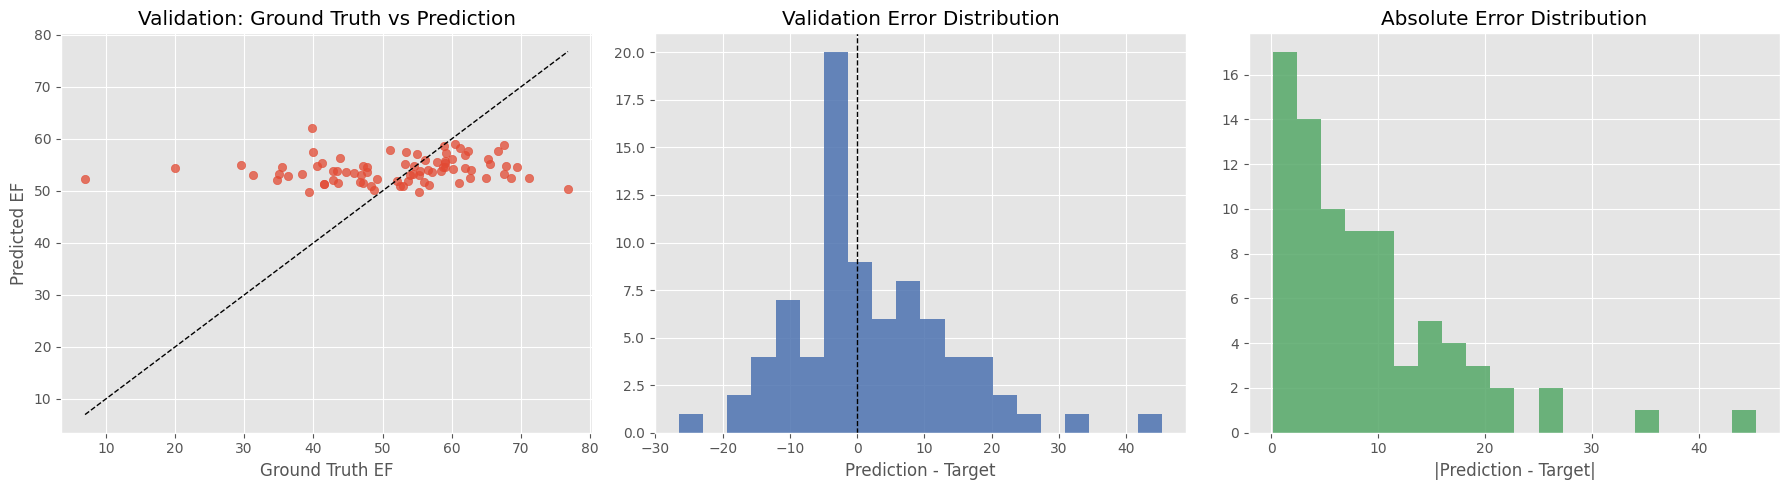

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(results_df['label'], results_df['prediction'], alpha=0.75)
lims = [
    min(results_df['label'].min(), results_df['prediction'].min()),
    max(results_df['label'].max(), results_df['prediction'].max()),
]
axes[0].plot(lims, lims, '--', color='black', linewidth=1)
axes[0].set_title('Validation: Ground Truth vs Prediction')
axes[0].set_xlabel('Ground Truth EF')
axes[0].set_ylabel('Predicted EF')

axes[1].hist(results_df['error'], bins=20, color='#4C72B0', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Validation Error Distribution')
axes[1].set_xlabel('Prediction - Target')

axes[2].hist(results_df['abs_error'], bins=20, color='#55A868', alpha=0.85)
axes[2].set_title('Absolute Error Distribution')
axes[2].set_xlabel('|Prediction - Target|')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'validation_overview_recomputed.png', dpi=200, bbox_inches='tight')
plt.show()


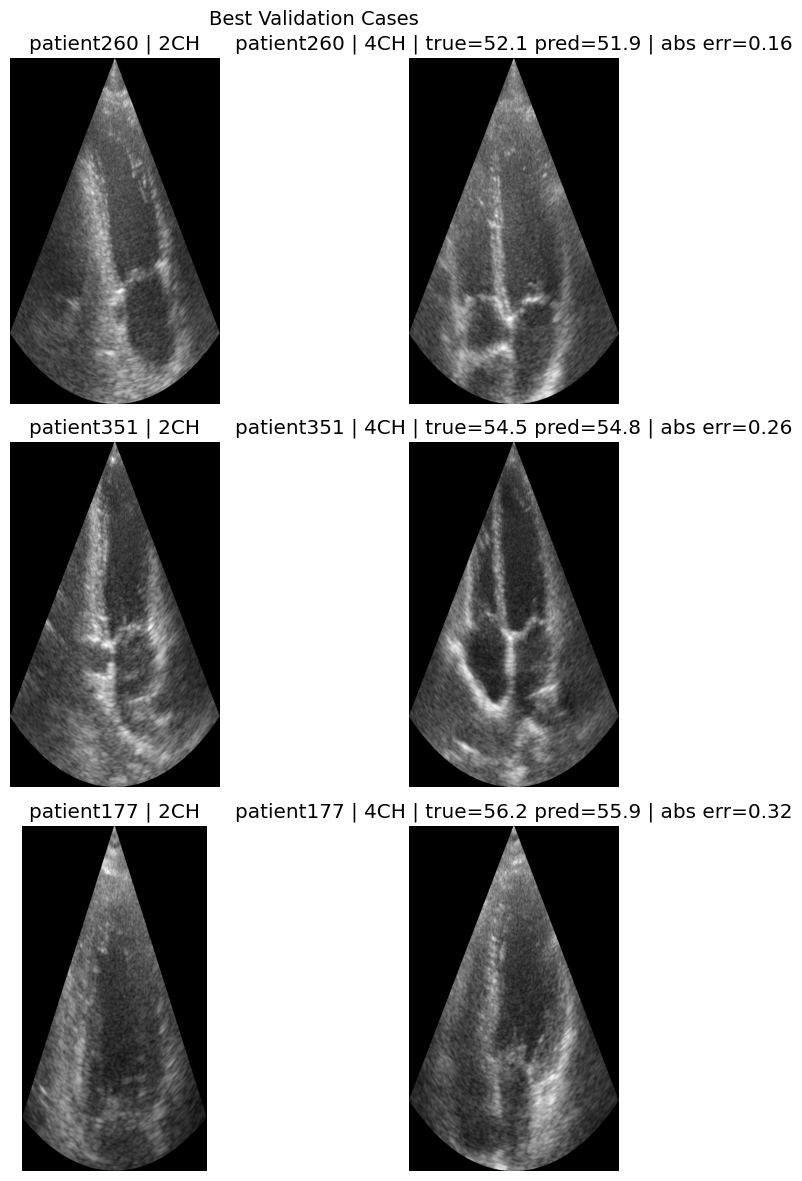

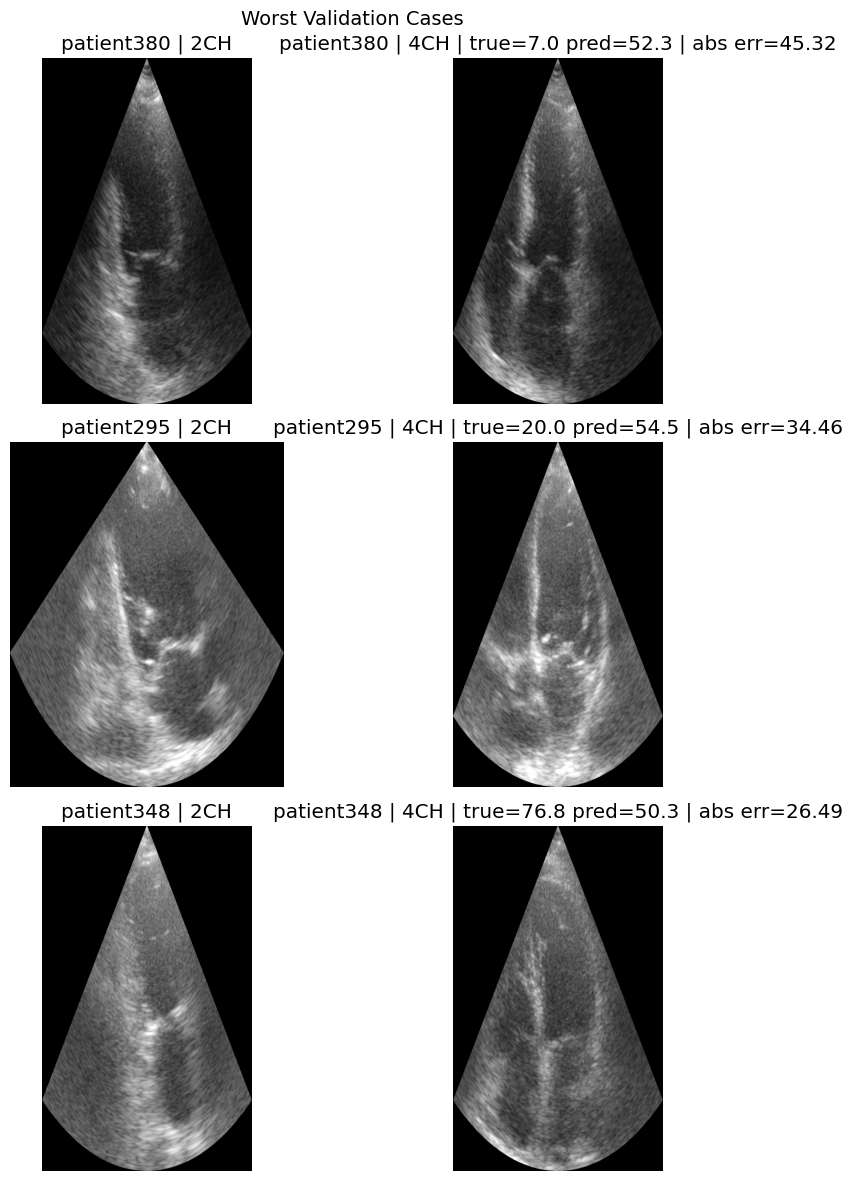

In [7]:
def show_case_grid(case_df: pd.DataFrame, title: str, output_path: Path, n_cases: int = 3) -> None:
    selected = case_df.head(n_cases).reset_index(drop=True)
    fig, axes = plt.subplots(len(selected), 2, figsize=(10, 4 * len(selected)))
    if len(selected) == 1:
        axes = np.array([axes])

    for row_idx, (_, row) in enumerate(selected.iterrows()):
        seq_2ch = load_raw_sequence(row['filepath_2ch'])
        seq_4ch = load_raw_sequence(row['filepath_4ch'])
        frame_2ch = seq_2ch[len(seq_2ch) // 2]
        frame_4ch = seq_4ch[len(seq_4ch) // 2]

        axes[row_idx, 0].imshow(frame_2ch, cmap='gray')
        axes[row_idx, 0].set_title(f"{row['patient_id']} | 2CH")
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(frame_4ch, cmap='gray')
        axes[row_idx, 1].set_title(
            f"{row['patient_id']} | 4CH | true={row['label']:.1f} pred={row['prediction']:.1f} | abs err={row['abs_error']:.2f}"
        )
        axes[row_idx, 1].axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()


best_cases_df = results_df.sort_values('abs_error').head(10).reset_index(drop=True)
worst_cases_df = results_df.sort_values('abs_error', ascending=False).head(10).reset_index(drop=True)

best_cases_df.to_csv(METRICS_DIR / 'top10_best_validation_cases_recomputed.csv', index=False)
worst_cases_df.to_csv(METRICS_DIR / 'top10_worst_validation_cases_recomputed.csv', index=False)

show_case_grid(best_cases_df, 'Best Validation Cases', FIGURES_DIR / 'best_cases_recomputed.png', n_cases=3)
show_case_grid(worst_cases_df, 'Worst Validation Cases', FIGURES_DIR / 'worst_cases_recomputed.png', n_cases=3)


In [8]:
comparison_path = METRICS_DIR / 'model_comparison.csv'
if comparison_path.exists():
    comparison_df = pd.read_csv(comparison_path)
    display(comparison_df.sort_values('rmse'))
else:
    print('model_comparison.csv not found yet. Run the training notebook first.')


,model,rmse,mae,r2
1,ridge_handcrafted_baseline,11.085055,8.748703,0.131010
0,train_mean_baseline,11.892564,9.383937,-0.000208
2,improved_dual_view_model,11.937667,8.847855,-0.007809
